In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = os.path.expanduser('~/Desktop/ecommerce-analysis/data/')

orders = pd.read_csv(data_path + 'olist_orders_dataset.csv')
customers = pd.read_csv(data_path + 'olist_customers_dataset.csv')
order_items = pd.read_csv(data_path + 'olist_order_items_dataset.csv')
payments = pd.read_csv(data_path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(data_path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(data_path + 'olist_products_dataset.csv')
sellers = pd.read_csv(data_path + 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(data_path + 'product_category_name_translation.csv')

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)


In [3]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("Order status counts:")
print(orders['order_status'].value_counts())

print("\nMissing values in orders:")
print(orders.isnull().sum())

print("\nDate range:")
print("From:", orders['order_purchase_timestamp'].min())
print("To:", orders['order_purchase_timestamp'].max())

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Missing values in orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Date range:
From: 2016-09-04 21:15:19
To: 2018-10-17 17:30:18


FileNotFoundError: [Errno 2] No such file or directory: '../data/monthly_sales_trend.png'

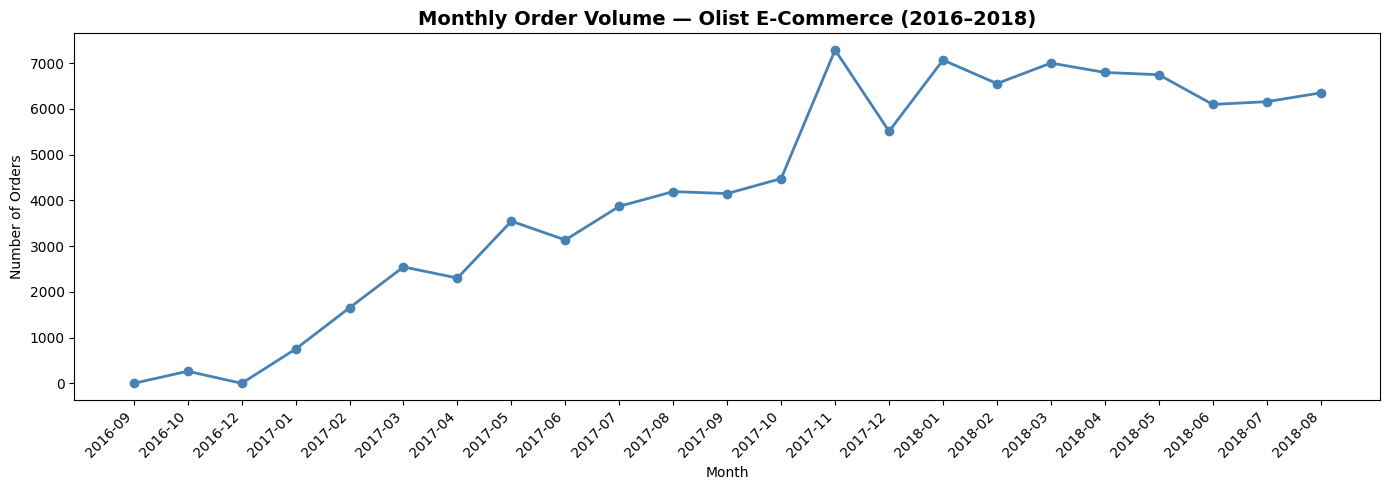

In [4]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders['month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = delivered_orders.groupby('month').size().reset_index(name='order_count')

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['month'].astype(str), monthly_sales['order_count'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Order Volume — Olist E-Commerce (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../data/monthly_sales_trend.png', dpi=150)
plt.show()

print("Peak month:", monthly_sales.loc[monthly_sales['order_count'].idxmax(), 'month'])
print("Peak orders:", monthly_sales['order_count'].max())

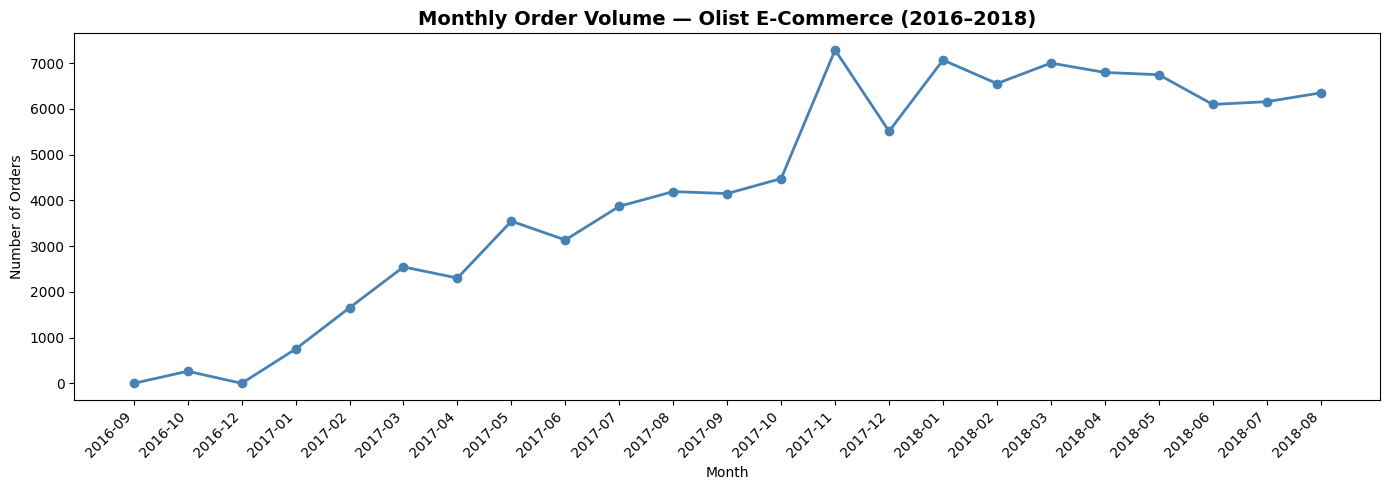

Peak month: 2017-11
Peak orders: 7289


In [5]:
import os

charts_path = os.path.expanduser('~/Desktop/ecommerce-analysis/data/charts/')
os.makedirs(charts_path, exist_ok=True)

delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = delivered_orders.groupby('month').size().reset_index(name='order_count')

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['month'].astype(str), monthly_sales['order_count'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Order Volume — Olist E-Commerce (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(charts_path + 'monthly_sales_trend.png', dpi=150)
plt.show()

print("Peak month:", monthly_sales.loc[monthly_sales['order_count'].idxmax(), 'month'])
print("Peak orders:", monthly_sales['order_count'].max())

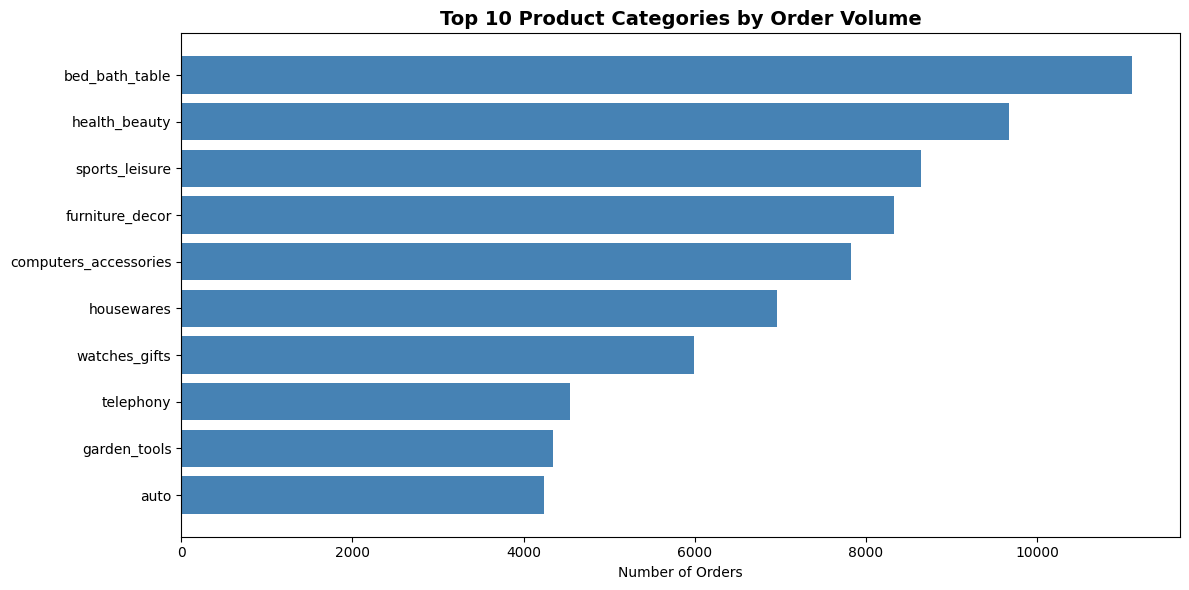

                 category  order_count
7          bed_bath_table        11115
43          health_beauty         9670
65         sports_leisure         8641
39        furniture_decor         8334
15  computers_accessories         7827
49             housewares         6964
70          watches_gifts         5991
68              telephony         4545
42           garden_tools         4347
5                    auto         4235


In [6]:
products_translated = products.merge(category_translation, on='product_category_name', how='left')

order_products = order_items.merge(products_translated, on='product_id', how='left')

top_categories = order_products.groupby('product_category_name_english')['order_id'].count().reset_index()
top_categories.columns = ['category', 'order_count']
top_categories = top_categories.sort_values('order_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_categories['category'], top_categories['order_count'], color='steelblue')
plt.xlabel('Number of Orders')
plt.title('Top 10 Product Categories by Order Volume', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(charts_path + 'top_categories.png', dpi=150)
plt.show()

print(top_categories)

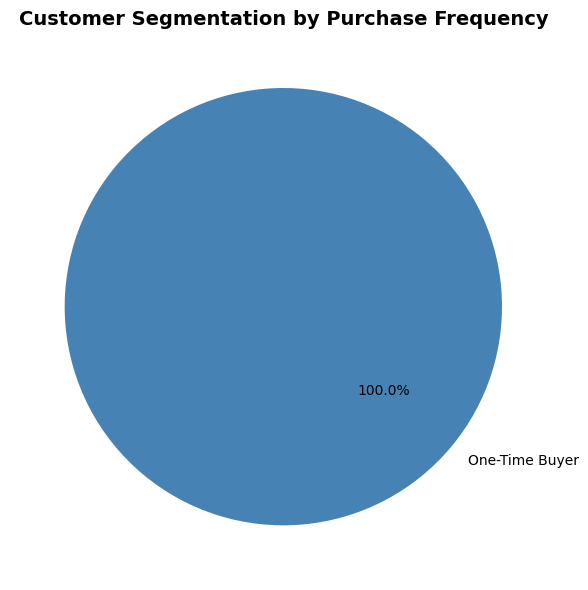

segment
One-Time Buyer    96478
Name: count, dtype: int64


In [7]:
customer_orders = orders[orders['order_status'] == 'delivered'].groupby('customer_id')['order_id'].count().reset_index()
customer_orders.columns = ['customer_id', 'total_orders']

customer_orders['segment'] = customer_orders['total_orders'].apply(
    lambda x: 'One-Time Buyer' if x == 1 else ('Repeat Buyer' if x <= 3 else 'Loyal Customer')
)

segment_counts = customer_orders['segment'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
        colors=['steelblue', 'cornflowerblue', 'lightsteelblue'], startangle=140)
plt.title('Customer Segmentation by Purchase Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(charts_path + 'customer_segmentation.png', dpi=150)
plt.show()

print(segment_counts)

Order frequency distribution:
total_orders
1    99441
Name: count, dtype: int64


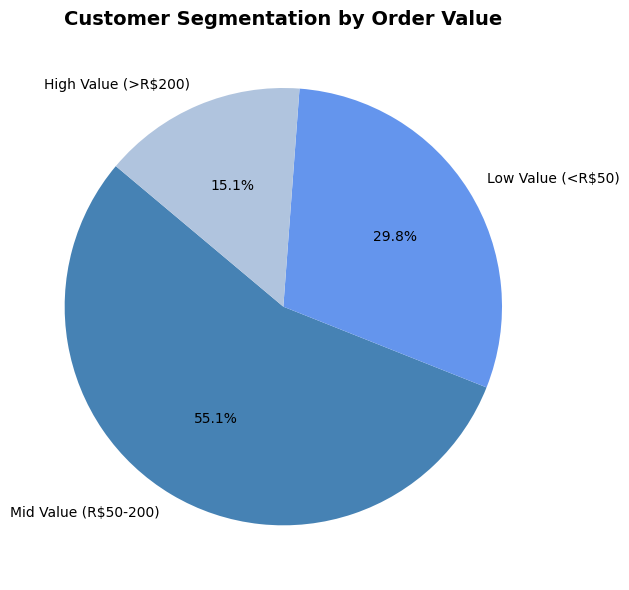

Average order value: R$ 137.04
Median order value: R$ 86.57
value_segment
Mid Value (R$50-200)    53149
Low Value (<R$50)       28791
High Value (>R$200)     14538
Name: count, dtype: int64


In [8]:
customer_orders2 = orders.groupby('customer_id')['order_id'].count().reset_index()
customer_orders2.columns = ['customer_id', 'total_orders']

print("Order frequency distribution:")
print(customer_orders2['total_orders'].value_counts().head(10))

order_value = order_items.groupby('order_id')['price'].sum().reset_index()
order_value.columns = ['order_id', 'total_value']

orders_with_value = orders.merge(order_value, on='order_id', how='left')
orders_with_value = orders_with_value[orders_with_value['order_status'] == 'delivered']

avg_order_value = orders_with_value['total_value'].mean()
median_order_value = orders_with_value['total_value'].median()

orders_with_value['value_segment'] = orders_with_value['total_value'].apply(
    lambda x: 'High Value (>R$200)' if x > 200 else ('Mid Value (R$50-200)' if x >= 50 else 'Low Value (<R$50)')
)

segment_counts2 = orders_with_value['value_segment'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(segment_counts2, labels=segment_counts2.index, autopct='%1.1f%%',
        colors=['steelblue', 'cornflowerblue', 'lightsteelblue'], startangle=140)
plt.title('Customer Segmentation by Order Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(charts_path + 'customer_segmentation.png', dpi=150)
plt.show()

print("Average order value: R$", round(avg_order_value, 2))
print("Median order value: R$", round(median_order_value, 2))
print(segment_counts2)

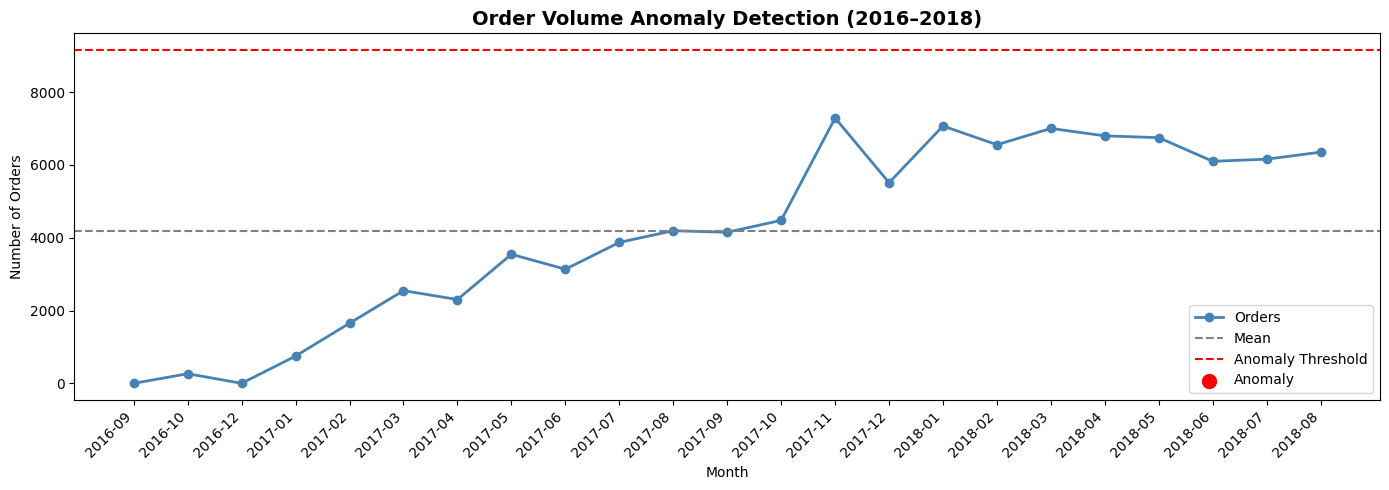

Anomalies detected:
Empty DataFrame
Columns: [month, order_count]
Index: []


In [9]:
monthly_sales['order_count_mean'] = monthly_sales['order_count'].mean()
monthly_sales['order_count_std'] = monthly_sales['order_count'].std()
monthly_sales['upper_bound'] = monthly_sales['order_count_mean'] + 2 * monthly_sales['order_count_std']
monthly_sales['lower_bound'] = monthly_sales['order_count_mean'] - 2 * monthly_sales['order_count_std']
monthly_sales['anomaly'] = (monthly_sales['order_count'] > monthly_sales['upper_bound']) | (monthly_sales['order_count'] < monthly_sales['lower_bound'])

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['month'].astype(str), monthly_sales['order_count'], marker='o', color='steelblue', linewidth=2, label='Orders')
plt.axhline(y=monthly_sales['order_count_mean'].iloc[0], color='gray', linestyle='--', label='Mean')
plt.axhline(y=monthly_sales['upper_bound'].iloc[0], color='red', linestyle='--', label='Anomaly Threshold')
anomalies = monthly_sales[monthly_sales['anomaly'] == True]
plt.scatter(anomalies['month'].astype(str), anomalies['order_count'], color='red', zorder=5, s=100, label='Anomaly')
plt.xticks(rotation=45, ha='right')
plt.title('Order Volume Anomaly Detection (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig(charts_path + 'anomaly_detection.png', dpi=150)
plt.show()

print("Anomalies detected:")
print(anomalies[['month', 'order_count']])

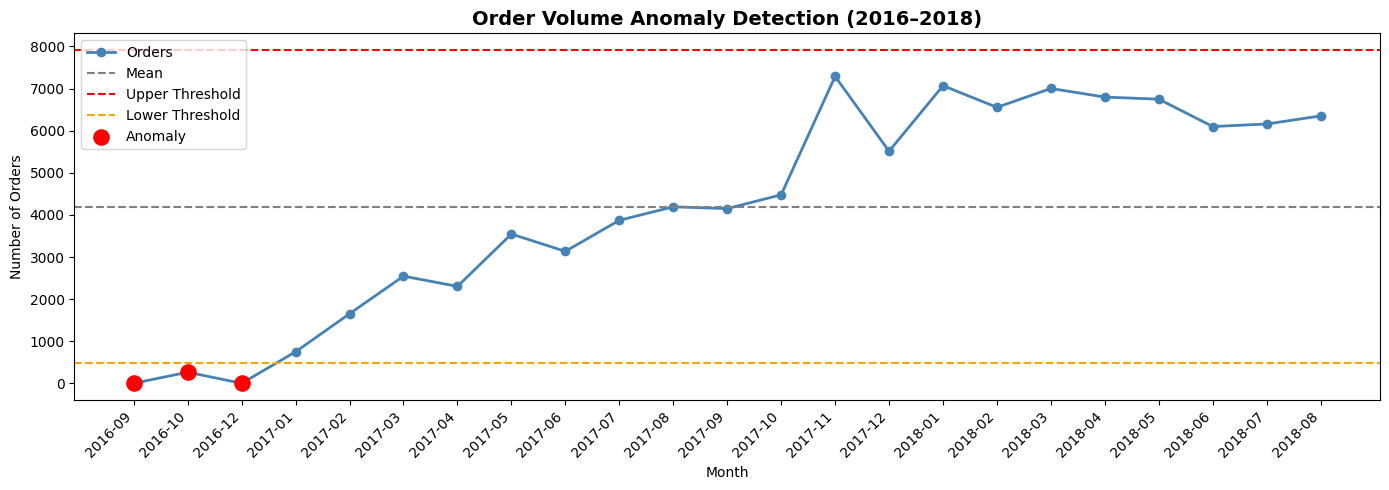

Anomalies detected:
     month  order_count
0  2016-09            1
1  2016-10          265
2  2016-12            1


In [10]:
monthly_sales['upper_bound'] = monthly_sales['order_count_mean'] + 1.5 * monthly_sales['order_count_std']
monthly_sales['lower_bound'] = monthly_sales['order_count_mean'] - 1.5 * monthly_sales['order_count_std']
monthly_sales['anomaly'] = (monthly_sales['order_count'] > monthly_sales['upper_bound']) | (monthly_sales['order_count'] < monthly_sales['lower_bound'])

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['month'].astype(str), monthly_sales['order_count'], marker='o', color='steelblue', linewidth=2, label='Orders')
plt.axhline(y=monthly_sales['order_count_mean'].iloc[0], color='gray', linestyle='--', label='Mean')
plt.axhline(y=monthly_sales['upper_bound'].iloc[0], color='red', linestyle='--', label='Upper Threshold')
plt.axhline(y=monthly_sales['lower_bound'].iloc[0], color='orange', linestyle='--', label='Lower Threshold')
anomalies = monthly_sales[monthly_sales['anomaly'] == True]
plt.scatter(anomalies['month'].astype(str), anomalies['order_count'], color='red', zorder=5, s=120, label='Anomaly')
plt.xticks(rotation=45, ha='right')
plt.title('Order Volume Anomaly Detection (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig(charts_path + 'anomaly_detection.png', dpi=150)
plt.show()

print("Anomalies detected:")
print(anomalies[['month', 'order_count']])

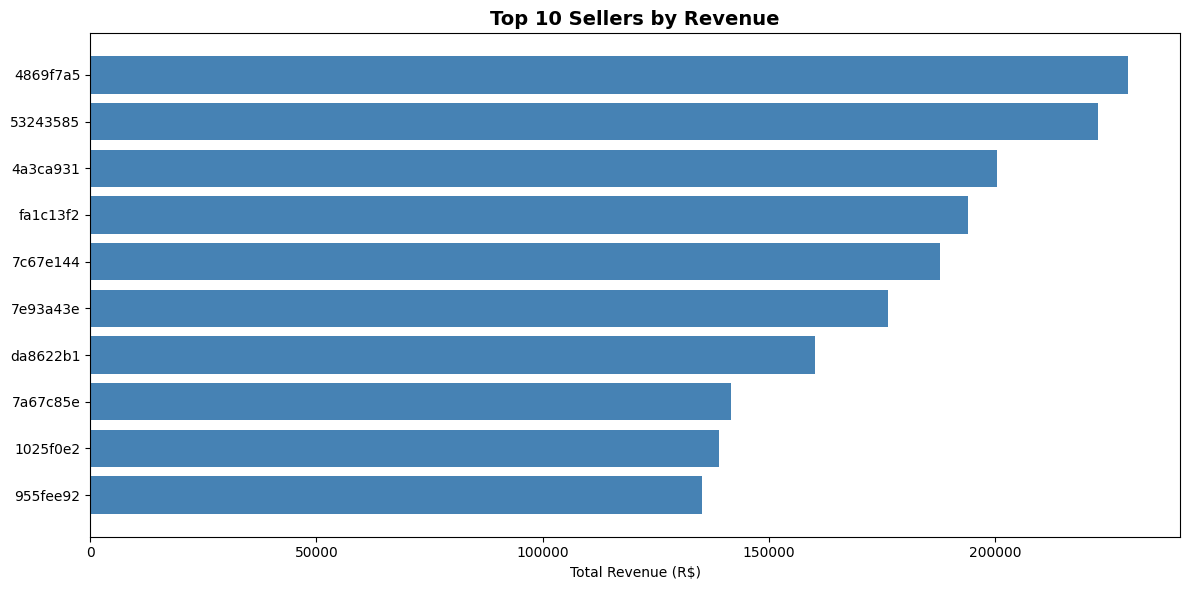

Top 10 sellers:
                             seller_id  total_orders  total_revenue  avg_order_value
857   4869f7a5dfa277a7dca6462dcf3b52b2          1156      229472.63       198.505735
1013  53243585a1d6dc2643021fd1853d8905           410      222776.05       543.356220
881   4a3ca9315b744ce9f8e9374361493884          1987      200472.92       100.892260
3024  fa1c13f2614d7b5c4749cbc52fecda94           586      194042.03       331.129744
1535  7c67e1448b00f6e969d365cea6b010ab          1364      187923.89       137.774113
1560  7e93a43ef30c4f03f38b393420bc753a           340      176431.87       518.917265
2643  da8622b14eb17ae2831f4ac5b9dab84a          1551      160236.57       103.311779
1505  7a67c85e85bb2ce8582c35f2203ad736          1171      141745.53       121.046567
192   1025f0e2d44d7041d6cf58b6550e0bfa          1428      138968.55        97.316912
1824  955fee9216a65b617aa5c0531780ce60          1499      135171.70        90.174583


In [11]:
seller_performance = order_items.groupby('seller_id').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean')
).reset_index()

seller_performance = seller_performance.sort_values('total_revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(seller_performance['seller_id'].str[:8], seller_performance['total_revenue'], color='steelblue')
plt.xlabel('Total Revenue (R$)')
plt.title('Top 10 Sellers by Revenue', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(charts_path + 'seller_performance.png', dpi=150)
plt.show()

print("Top 10 sellers:")
print(seller_performance[['seller_id', 'total_orders', 'total_revenue', 'avg_order_value']].to_string())

In [12]:
print("=" * 50)
print("E-COMMERCE ANALYSIS SUMMARY")
print("=" * 50)
print(f"Total orders analysed: {len(orders):,}")
print(f"Total delivered orders: {len(delivered_orders):,}")
print(f"Date range: Sept 2016 – Oct 2018")
print(f"Peak month: November 2017 (Black Friday) — 7,289 orders")
print(f"Top category: Bed & Bath Table — 11,115 orders")
print(f"Average order value: R${round(avg_order_value, 2)}")
print(f"Top seller revenue: R$229,472")
print(f"Anomalies detected: 3 months (platform launch period)")
print("=" * 50)

E-COMMERCE ANALYSIS SUMMARY
Total orders analysed: 99,441
Total delivered orders: 96,478
Date range: Sept 2016 – Oct 2018
Peak month: November 2017 (Black Friday) — 7,289 orders
Top category: Bed & Bath Table — 11,115 orders
Average order value: R$137.04
Top seller revenue: R$229,472
Anomalies detected: 3 months (platform launch period)
